Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [2]:
NAME = "Angelina Podolako"
STUDENT_NUMBER = "s1125886"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Notebooks to make your assignments, it might remove the auto-grading metadata. To prevent this, please copy the answers back into the original notebook.
- Only type your answers in places where asked.   

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You can remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 5

### Deadline: December 11th

In this assignment, we are going to practice the following things:
 - SVM: creating the decision boundary, finding the support vectors
 - SVM: selecting different kernels
 - Collaborative filtering with Funk SVD
 - The Apriori algorithm

Note, for exercise 2, we need the package `mlxtend`, check the cell below how to install it:

Note that if you do not specify the version of this package, it might update your version of SKlearn, which might interfere with other exercises.

In case anything is broken, creating the following Conda environment should work for this course:

```
conda create -n fromdatatomodel python=3.11 scikit-learn=1.3.0 numpy=1.24.3 plotly=5.9.0  pandas=1.5.3 
conda activate fromdatatomodel
pip install jupyterlab==4.2.4 mlxtend==0.20.0 seaborn==0.12.2 matplotlib==3.7.1
```

Check Brightspace - Extra Materials for more information on how to use this.

In [7]:
# Uncomment

#!pip install mlxtend==0.20.0

In [8]:
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import pairwise_distances

from scipy.sparse.linalg import svds

from mlxtend.frequent_patterns import apriori, association_rules

### Exercise 1.1

In this exercise, we will look at several aspects of Support Vector Machines, focusing on the practical side.

To understand the workings of SVMs, we will primarily work on generated data.

We will first use the `make_blobs` function in sklearn, which generates random blobs of data. 

Investigate the resulting plot below.

### Make sure to, in every exercise, call the instance of your classifier `clf`

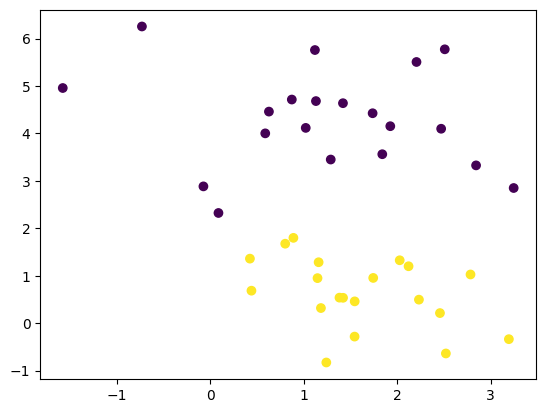

In [10]:
X, y = make_blobs(n_samples=40, centers=2, random_state=0) #40 dots with 2 centrs(classes)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

### Exercise 1.1.1

Remember, that in SVM's, we try to minimize 
$$\frac{1}{2} w^T w + C \sum p_i$$ with $C$ as balance parameter and  $p_i$ as a slack parameter
    such that 
    $$y_i(w^Tx_i + b) \geq 1 - p_i$$


Let us start with fitting an SVM for the blobs we generated above to get more insight into the influence of this $C$. 

Let us first draw an SVM with a high value for $C$, meaning that mistakes are heavily penalized. Fit an [svm.LinearSVM](https://scikit-learn.org/dev/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC) using $C = 1000$, simulating the SVM version that does not allow for mistakes. For other parameters, use as loss function the `loss="hinge"`, and set `dual=True` to prevent getting a `Future Warning`. Use the provided random state.


In this assignment, we will use the [Decision Boundary Display estimator](https://scikit-learn.org/dev/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html#sklearn.inspection.DecisionBoundaryDisplay.from_estimator) several times.
This allows you to visualize the decision boundaries in your plots.

The solid line will signify the line $y_i(w^Tx_i + b) = 0$, and the dashed lines will signify $y_i(w^Tx_i + b) = \pm 1$

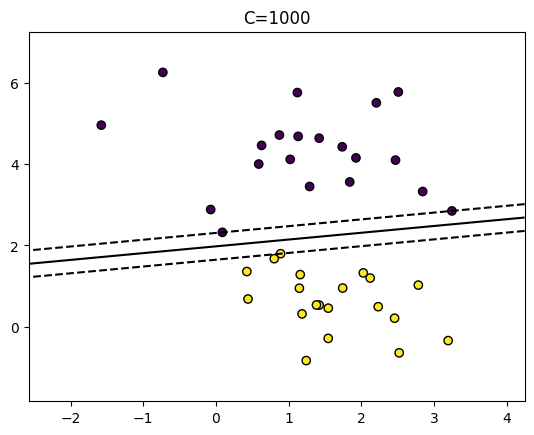

In [12]:
C = 1000
random_state = 42
clf = None

# YOUR CODE HERE
clf = svm.LinearSVC(loss="hinge", dual=True, C=C, max_iter=2000, random_state=random_state) #high C=allow not mistakes=sensitive to outliers; dual=prevent FutureWarnings
clf.fit(X, y)

display = DecisionBoundaryDisplay.from_estimator(
    clf, #fitted model
    X, #2d massive(matrix n sampl*n features)
    response_method="decision_function", #methos to get predicts = distance to bound = “soft” score for each sample in relation to each class,
    plot_method="contour",  # using lines for the decision function =Метод визуализации=Строит контуры без заполнения.
    levels=[-1, 0, 1],  # fitting the lines -1, 0 and 1
    linestyles=["--", "-", "--"],  # using dashed lines and solid lines to plot those
    colors="k",
)
display.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")#coords on X axis, yaxis, color=depend if class y

plt.title("C=" + str(C))
plt.show()

In [13]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

## Exercise 1.1.2

Using the `clf.decision_function` (see the documentation of SVMs above), we will get the output of $w^tx + b$ for all datapoints $x$. Remember that **support vectors** are the values most responsible for the decision boundaries, i.e., the values for which
$$|w^tx_i + b| \leq 1$$.


Compute all data points that are support vectors, e.g., all $x \in X, |w^tx_i + b| \leq 1 + \epsilon$.

`support_vectors_when_1000` should be a np array of shape $(M, 2)$, and a subset of $X$.


(Note, because of the way floating values are implemented in Python, it is probably better to compare with $1+ \epsilon$, with $\epsilon$ a small value )


In [15]:
decision_function = clf.decision_function(X)  #return distance to separable hyperplane(as larger as harder model) = w^T *x + b for all x
support_vectors_when_1000 = None
epsilon = 0.0001
# YOUR CODE HERE
support_vectors_tf_classifier = np.abs(decision_function) <= (1+epsilon) #support vectors= ∣w^T * xi​ +b∣ ≤1 =[-1,1]; True/False for each x; subset X =x∈X, для которых ∣wTxi​+b∣≤1+ϵ,ϵ —небольшое значение для учета погрешности

support_vectors_when_1000 = X[support_vectors_tf_classifier] #(M, 2), M - количество опорных векторов;values instead of true false

print(support_vectors_when_1000)

[[0.89011768 1.79849015]
 [3.2460247  2.84942165]
 [0.08848433 2.32299086]]


In [16]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

Use the following plot to see if you found the correct support vectors:
This plot will draw an extra circle around the support vectors. 

If you did it correctly, all dots exactly on the line should have an extra circle.

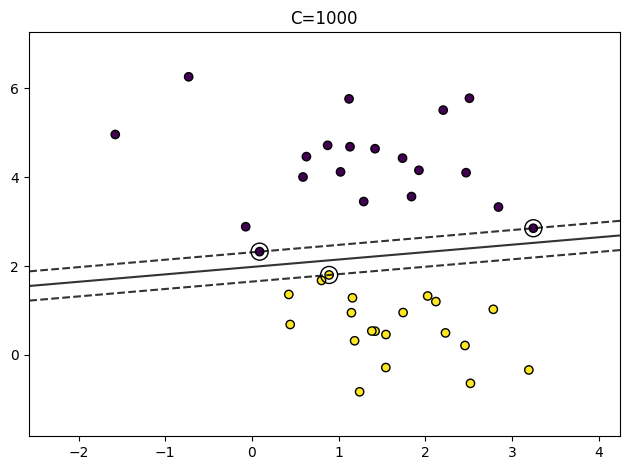

In [18]:
# Plotting the decision boundary
display = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function", # построениe контурных линий= значения функции решения.
    plot_method="contour",  # using lines for the decision function =Метод визуализации=Строит контуры без заполнения.
    levels=[-1, 0, 1],  # fitting the lines -1, 0 and 1
    linestyles=["--", "-", "--"],  # using dashed lines and solid lines to plot those
    colors="k",
    alpha=0.8,
)
display.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")

# We add an extra scatter plot for the support vectors, where we add an extra, slightly bigger transparent circle,
# on top of the normal scatter plot.
display.ax_.scatter(
    support_vectors_when_1000[:, 0],  #1st col = x coord
    support_vectors_when_1000[:, 1],  #2nd col = y coord
    s=150, #size
    facecolors="none", #transparent color
    edgecolors="k",
)

plt.title("C=" + str(C))
plt.tight_layout()
plt.show() #normal spectors = 3

### Exercise 1.1.3


Perform the exercise above again, but this time, set $C = 0.1$

Use the provided random state again.

Compute the list of support vectors so you can recreate the plot in the cell directly above but with a different value of $C$

How many support vectors do you see now? Is that what you expected when $C$ has a lower value of 0.1?


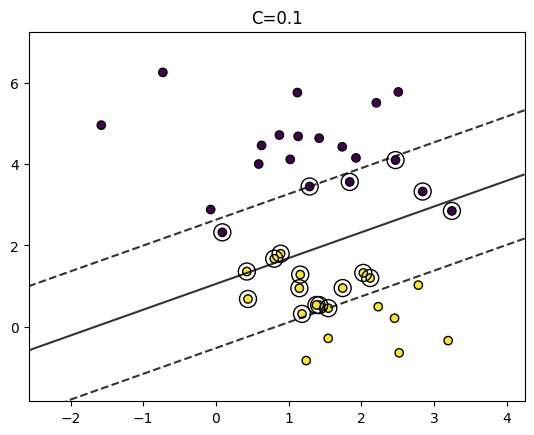

19


In [20]:
C = 0.1
clf = None
decision_function = None
support_vectors_when_01 = None
# YOUR CODE HERE
clf = svm.LinearSVC(loss="hinge", dual=True, C=C, max_iter=2000, random_state=random_state) #high C=allow not mistakes=sensitive to outliers; dual=prevent FutureWarnings
clf.fit(X, y)

decision_function =  clf.decision_function(X) #return distance to separale hyperplane(as larger as harder model) = w^T *x + b for all x
support_vectors_tf_classifier = np.abs(decision_function) <= (1+epsilon) #support vectors= ∣w^T * xi​ +b∣ ≤1 =[-1,1]; True/False for each x; subset X =x∈X, для которых ∣wTxi​+b∣≤1+ϵ,ϵ —небольшое значение для учета погрешности

support_vectors_when_01 = X[support_vectors_tf_classifier] #(M, 2), M - количество опорных векторов;values instead of true false


# Plotting the decision boundary
display = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    levels=[-1, 0, 1],
    plot_method="contour",
    linestyles=["--", "-", "--"],
    colors="k",
    alpha=0.8,
)
# Plotting the datapoints
display.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
# Putting an extra circle around the support vectors
display.ax_.scatter(
    support_vectors_when_01[:, 0],
    support_vectors_when_01[:, 1],
    s=150,
    facecolors="none",
    edgecolors="k",
)


plt.title("C=" + str(C))
plt.show()

print(len(support_vectors_when_01)) #too much spectors = 19

In [21]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.2.1

In the following exercise, we will load a few datasets with weird shapes, for which we have already made the train-test split and saved them as an [npy file](https://numpy.org/devdocs/reference/generated/numpy.lib.format.html).

Use the [SKlearn svm function](https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) to fit an SVM on all of these, with different kernels. 

Try to find a kernel (pick from 'linear', 'poly', 'rbf' ) and value for C, for polynomials their `degree` and for rbf the parameter `gamma`, that will create a reasonable decision boundary for these shapes.


Remember that the polynomial kernel looks like $K(x_i , x_j)=(x_i x_j + c)^d$, and the rbf kernel looks like $K(x_i , x_j) = e^{-\gamma||x_i  - x_j||^2}$. The Linear kernel is the same as what we did in the exercise above. 


The first shape is a circle within a circle. Try getting an accuracy of at least 0.8 

NOTE: None of these datasets are perfectly separable. It might crash your Kernel (i.e, the Jupyter Lab Kernel, not the SVM Kernel) when fitting an SVM with a large value of `C` (meaning you try to find a decision boundary that separates the classes perfectly). When you do not see a result after 30 seconds, it is probably best to interrupt and restart your Kernel with Kernel> Interrupt Kernel. 


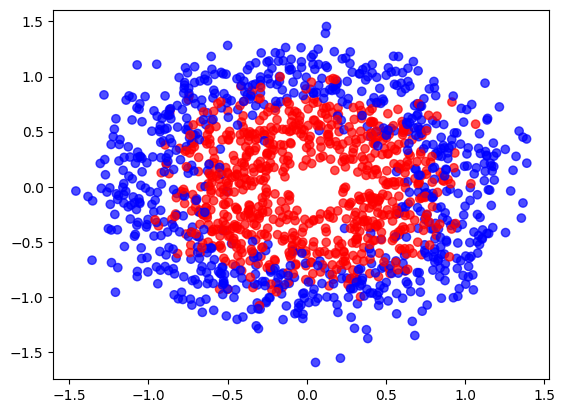

In [23]:
with open("circles.npy", "rb") as f:
    X_train = np.load(f)
    X_test = np.load(f)
    y_train = np.load(f)
    y_test = np.load(f)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.7)
plt.show()

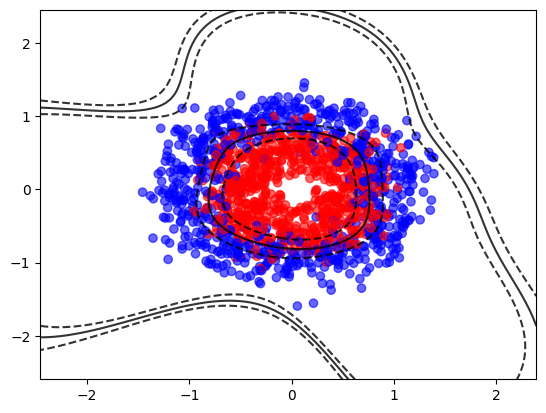

In [24]:
clf = None

# YOUR CODE HERE
#for rbf - gamma -  like circles - K(xi​,xj​)=e^ (−γ∣∣xi​−xj​∣∣^2)
clf = svm.SVC(kernel='rbf', C=1000, gamma="auto") #gamma"scale" makes 0.816, gamma=0.01 makes 0.816
clf.fit(X_train, y_train)


display = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_train,
    response_method="decision_function",
    levels=[-1, 0, 1],
    plot_method="contour",
    linestyles=["--", "-", "--"],
    colors="k",
    alpha=0.8,
)
display.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.6)
plt.show()

In [25]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.822


In [26]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.2.2

Next, we will load spiral type of data. Try fitting an SVM that gets an accuracy of at least 0.95

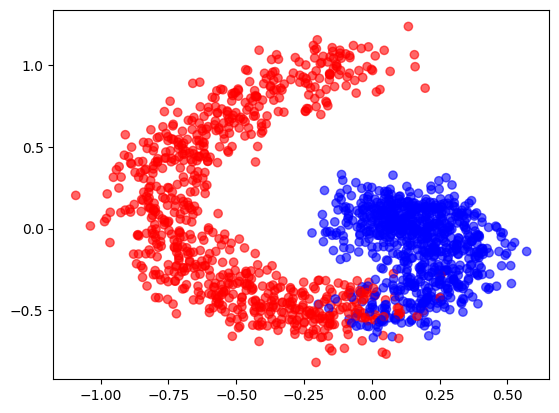

In [28]:
with open("spirals.npy", "rb") as f:
    X_train = np.load(f)
    X_test = np.load(f)
    y_train = np.load(f)
    y_test = np.load(f)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.6)
plt.show()

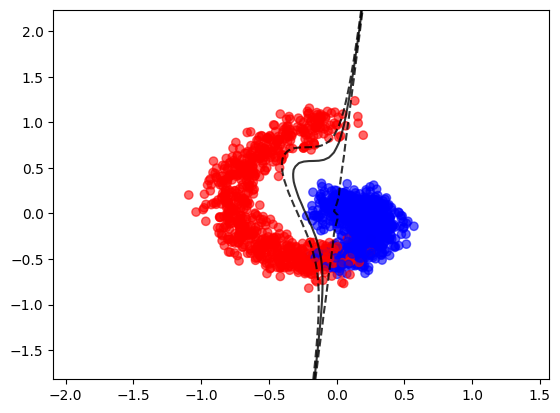

In [29]:
clf = None


# YOUR CODE HERE
#for polynomial kernel = choose degree - nonlinear -K(xi​,xj​)=(xi​xj​+c)^d 
clf = svm.SVC(kernel='poly', degree=3, C=1000) #gamma"scale" makes accuracy 0.966, can be used with polys, but no sence here
clf.fit(X_train, y_train)

display = DecisionBoundaryDisplay.from_estimator(
    clf,
    X_train,
    response_method="decision_function",
    levels=[-1, 0, 1],
    plot_method="contour",
    linestyles=["--", "-", "--"],
    colors="k",
    alpha=0.8,
)
display.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", alpha=0.6)
plt.show()

In [30]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.97


In [31]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.2.3
The last interesting shape we are going to fit is a heart:

For this one, we will use four-fold cross-validation. We have already made the four folds for you.
Remember that this means that we will split the data into four equal parts every time you train on three of these four parts and evaluate the remaining one.

Ensure the parameters and model you use are identical for all four folds.

We will plot the decision boundary and score for all four folds.

Try at least getting an accuracy on the test set of 0.9; remember that this total accuracy is the mean of the accuracy for all models. 

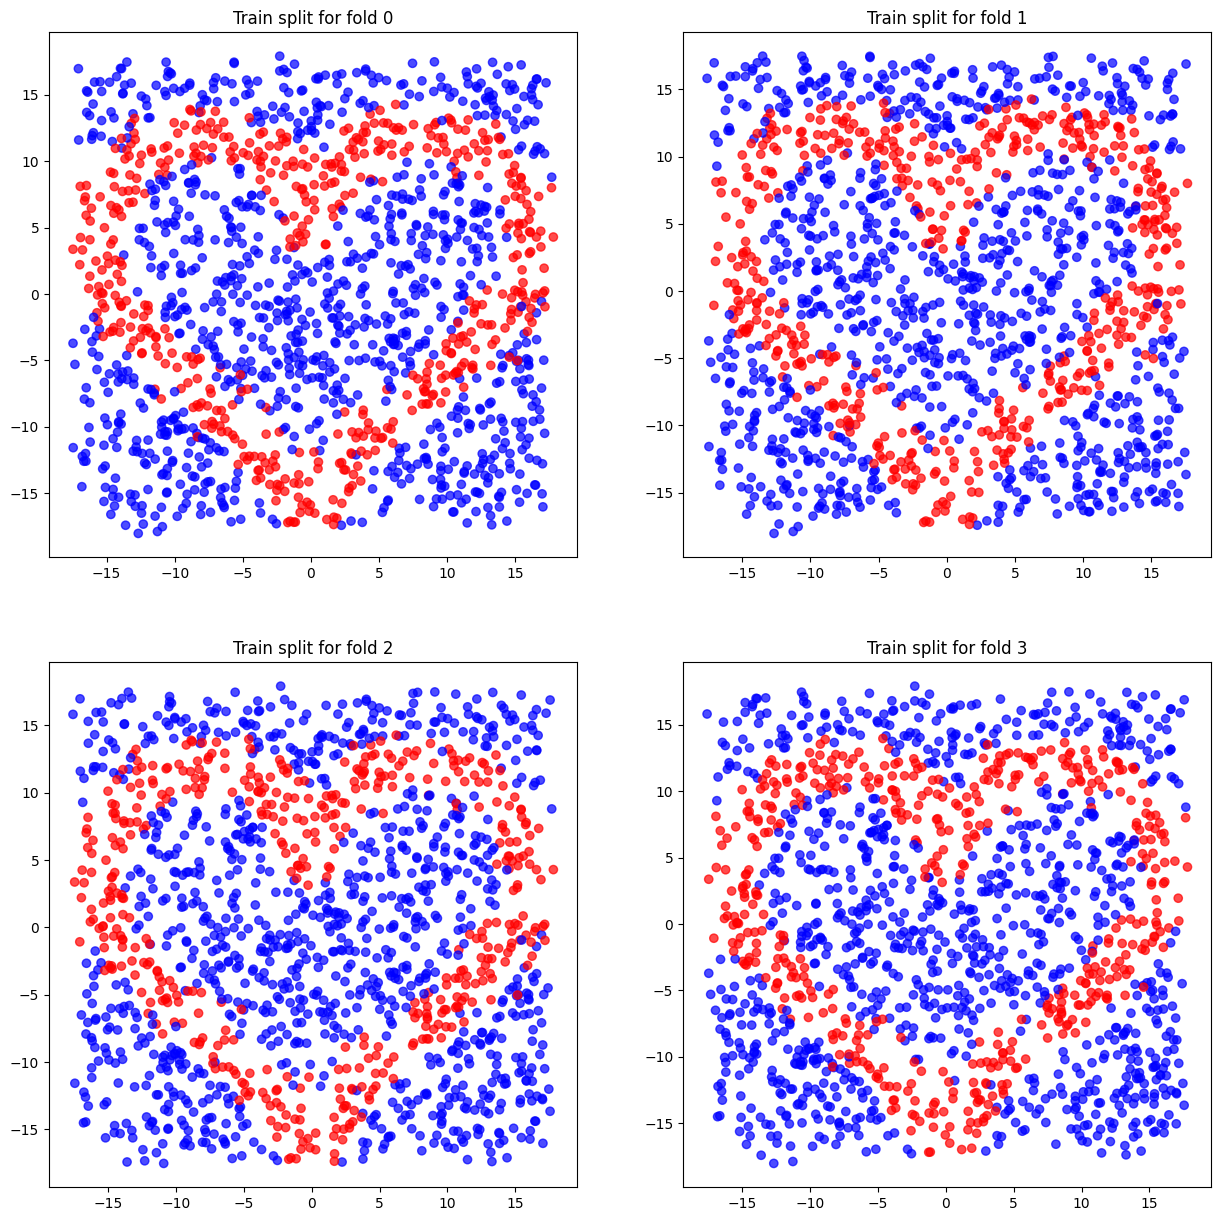

In [33]:
four_folds = {0: {}, 1: {}, 2: {}, 3: {}}

with open("heart.npy", "rb") as f:
    for i in four_folds:
        four_folds[i]["X_train"] = np.load(f)
        four_folds[i]["X_test"] = np.load(f)
        four_folds[i]["y_train"] = np.load(f)
        four_folds[i]["y_test"] = np.load(f)

fig, ax2d = plt.subplots(2, 2, figsize=(15, 15), squeeze=False)
axlist = ax2d.flatten()  # Used for making the subplots

for i, ax in enumerate(axlist):
    ax.scatter(
        four_folds[i]["X_train"][:, 0],
        four_folds[i]["X_train"][:, 1],
        c=four_folds[i]["y_train"],
        cmap="bwr",
        alpha=0.7,
    )
    ax.set_title(f"Train split for fold {i}")

In [34]:
# Take a look at what four_folds looks like:
# Don't forget to comment out this cell again when handing it in, because the print statement will probably be long.

# four_folds[0]

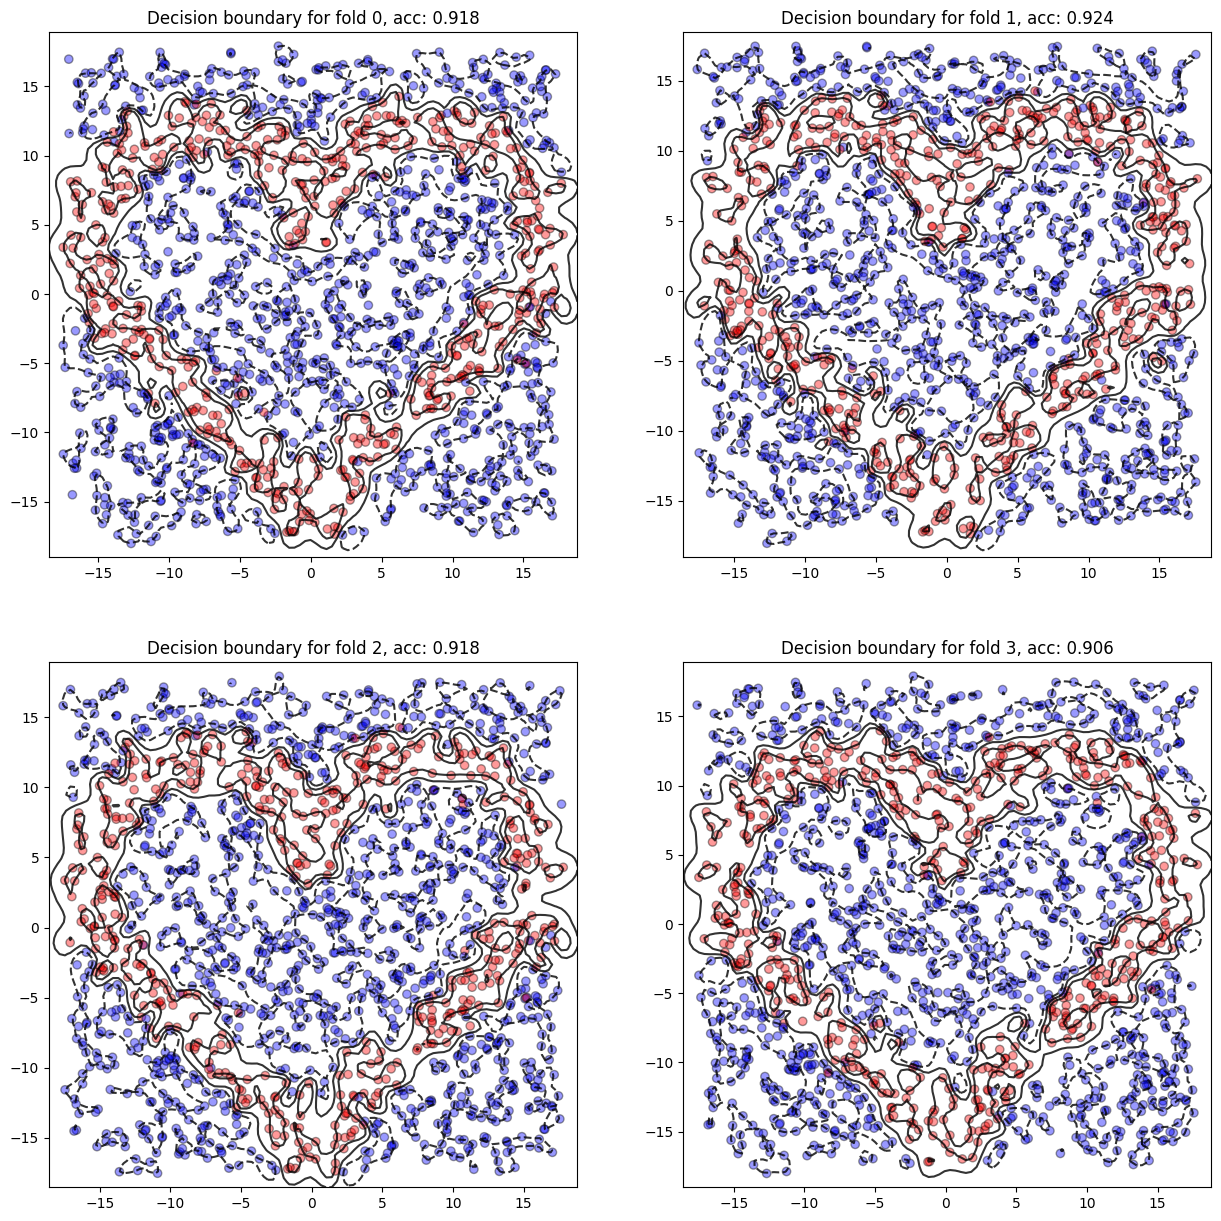

In [35]:
accuracies = []  # Used to store the accuracies

fig, ax2d = plt.subplots(2, 2, figsize=(15, 15), squeeze=False)
axlist = ax2d.flatten()

for i, ax in enumerate(axlist):
    clf = None

    # YOUR CODE HERE
    clf = svm.SVC(kernel='rbf', C=10, gamma = 1) 
    clf.fit(four_folds[i]["X_train"], four_folds[i]["y_train"])

    y_pred = clf.predict(four_folds[i]["X_test"])
    accuracies.append(accuracy_score(four_folds[i]["y_test"], y_pred))
    display = DecisionBoundaryDisplay.from_estimator(
        clf,
        four_folds[i]["X_train"],
        response_method="decision_function",
        levels=[-1, 0, 1],
        plot_method="contour",
        colors="k",
        alpha=0.8,
        ax=ax,
    )

    display.ax_.scatter(
        four_folds[i]["X_train"][:, 0],
        four_folds[i]["X_train"][:, 1],
        c=four_folds[i]["y_train"],
        cmap="bwr",
        edgecolors="k",
        alpha=0.4,
    )
    ax.set_title(f"Decision boundary for fold {i}, acc: {accuracies[i]}")

In [36]:
# Computing the mean of all accuracies for a final score
accuracy = np.mean(accuracies)
print(accuracy) #total accuracy is the mean of the accuracy for all models.

0.9165000000000001


In [37]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

# Part for WEEK 11:

Note that this part is to be done after you have attended the 11th lecture. 

However, for this week, 2.1 is probably already doable. The first part is mostly data processing, and then we are using SVD, which we have already seen in week 8.
2.2 is probably really best done after attending lecture 11. 

### Exercise 2.1 

We will use a small part of the Movie Lens dataset for both recommendation systems and Apriori learning. This dataset is one of the most important datasets in recommender systems research and includes millions of ratings for thousands of users and movies. 


To ensure everyone can run this exercise on their local hardware, however, we will be using the official small subset; read more about it [here](https://files.grouplens.org/datasets/movielens/ml-latest-small-README.html). 


First, load the file and look at movies and ratings. 

In [39]:
ratings = pd.read_csv("ml-latest-small/ratings.csv", encoding="latin-1")
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


### Exercise 2.1.1

Having the movies represented as IDs is inconvenient for exploring our results.
Using the `movies.csv` file, make a dictionary named `movie_names_dict`, where the keys are the movie IDs and the values are the names of the movies.
To test if you did it correctly, `movie_names_dict[34072]` should equal to the movie `March of the Penguins (Marche de l'empereur, La) (2005)`

To ensure everything works correctly with character encoding, it is probably best to use the argument `encoding='latin-1'` in the function `read_csv`. 


In [41]:
movie_names_dict = {}

# YOUR CODE HERE
movies = pd.read_csv("ml-latest-small/movies.csv", encoding="latin-1") #encoding param to prevent problems with coding

for i, row in movies.iterrows():
    movie_names_dict[row['movieId']] = row['title'] #key = value for each row
    
print(movie_names_dict[34072]) #result needs be "March of the Penguins (Marche de l'empereur, La) (2005)"
movies#to check how it looks like and which data has

March of the Penguins (Marche de l'empereur, La) (2005)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [42]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.2

The `ratings` DataFrame is currently stored in the `long` form, i.e. every stored user-item interaction has its own row in the DataFrame.
However, we need to convert this to a sparse matrix to use SVD.

Using the [pivot method in pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html), pivot this DataFrame to a matrix called `ratings_matrix`.

The columns of `ratings_matrix` should be the movieId, of which we have 9724. The rows should be the userID, of which we have 610. The values should be the ratings if the user rated the movie, and a 0 if the user did not rate the movie.

The result is thus a matrix of shape $(610, 9724)$.

In [44]:
ratings_matrix = None

# YOUR CODE HERE
ratings_matrix = ratings.pivot(index= 'userId' , columns='movieId', values='rating' )  #from long ratind_df to sparse(wide) matrix using SVD
ratings_matrix = ratings_matrix.fillna(0) #fill NaN with 0 -has not yet reviewed =e.g. userId watched only movieId 1,2 but not 3, then 3=Nan=0

ratings_matrix.shape #needs be (610,9724)
ratings_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,2.5,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.3

Let's make a recommender system for ourselves in this exercise! For that, we need to add a row to our DataFrame, where you put some movies you like.
Using either `movie_names_dict` or your favorite CSV editor and the file `ml-latest-small/movies.csv`, make a NumPy array that includes the IDs as integers of at least ten movies you liked seeing (the more you put in, the better it will work).

I gave you three penguin-related movies to get started, but you do not have to use them.

Then, using the column names, stored in `ratings_matrix.columns`, make a NumPy array of shape (1, 9724) called `movies_I_like_array`, where you have 5s for the movies you liked, and 0s for the rest.

Then, using [pd.concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html), make a new DataFrame called `ratings_matrix_plus_me`, where you append your ratings to the bottom of `ratings_matrix`. This should result in a DataFrame of shape (611, 9724). 
Make sure the row which represents you is the last row. 

In [47]:
# Example of movies:
movies_I_like = np.array([34072, 49274, 117851])
movies_I_like_array = None
ratings_matrix_plus_me = None
# YOUR CODE HERE
movies_I_like = np.array([116, 4896, 2959, 4993, 527, 8974, 102666, 167296, 47, 4306, 6365])#id of films i like

movies_I_like_array = np.zeros((1, ratings_matrix.shape[1])) #matrix of 0, cols as in rating_matrix
for movie in movies_I_like:
    if movie in ratings_matrix.columns:  #  exists in the matrix?
            movie_index = ratings_matrix.columns.get_loc(movie) #index of movie film ----because shape(1,djfw) needed))))))))))))))0
            movies_I_like_array[0, movie_index] = 5 

movies_I_like_df = pd.DataFrame(movies_I_like_array, columns=ratings_matrix.columns) #convert array to dataframe with same col names

ratings_matrix_plus_me = pd.concat([ratings_matrix, movies_I_like_df], ignore_index=True) #now ignore inex)))))))))))0

print(movies_I_like_array.shape)
print(ratings_matrix_plus_me.shape)

(1, 9724)
(611, 9724)


In [48]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.4

Remember that by using SVD, we can break up a Matrix into three parts:

$$SVD(X) = U \Sigma V^T $$

Previously, we used SVD to compute the PCA. This time, we will use the so-called Funk SVD method to make feature vectors for users and items. Because of that, we are not interested in computing the _full_ SVD but only a limited amount of features, in this case, 50.
This will result in three matrices of the shape: Shape $U$: (N_Users, 50), shape $\Sigma$: (50, 50), shape $V^T$: (50, N_movies).
U will here represent the Users, and V will represent the movies. 

We will normalize the matrix to prepare it for SVD by converting it to a NumPy array and subtracting the mean per user from each user.

Using SVDs in [scipy.sparse.linalg](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.svds.html), we can get the SVD and automatically truncate it to only using the first 50 singular values. Assign the results of this to the variables U, sigma, Vt.



In [50]:
R = ratings_matrix_plus_me.to_numpy() #onvert ratings matrix to array
user_ratings_mean = np.mean(R, axis=1) #compute mean of each user accross all movies
Ratings_demeaned = R - user_ratings_mean.reshape(-1, 1) #subtract mean from each user rating

U, sigma, Vt = None, None, None
k = 50
# YOUR CODE HERE
U, sigma, Vt = svds(Ratings_demeaned, k=k)  #SVD on Ratings_demeaned matrix=отклонение от среднего

print(U.shape) #user
print(Vt.shape) #film

(611, 50)
(50, 9724)


In [51]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.5

The matrix `Vt`, shaped (50, 9724), can now be seen as a latent representation of all our movies. You can interpret this as all 9724 movies with a (1,50) shaped vector representing the movie. 
The vectors for these movies should be similar if similar people like the movies. 

Using the using the dictionary `movie_names_dict_index`, the matrix $V$, the vector of the movie `find_closest_to`, and [pairwise distances](https://scikit-learn.org/dev/modules/generated/sklearn.metrics.pairwise_distances.html), find the movies with the lowest distance to the Lion King, which has index `i = 332`. 

If you implemented it correctly, the other closest movies should also be Disney movies.
`most_similar` should be a sorted list of movie titles, where the 0th one is the most similar, and the last one is the least similar.

Note: If you want to play around and see other similar movies, go ahead! However, for the purpose of the evaluation, please set back `i=322` before handing in the assignment.

In [53]:
most_similar = []
movie_names_dict_index = {i: movies["title"][i] for i in range(len(movies["title"]))} #map index to title - find title by index
V = Vt.T #latent repr of all movies
i = 322 #Lion KIng
print(f"Going to find the movie closest to {movie_names_dict_index[i]}")

find_closest_to = V[i].reshape(1, -1) #latent Lion King to vector

# YOUR CODE HERE
distances = pairwise_distances(find_closest_to, V)  #pairwise distance from Lion to each other
similar_movie_indices = distances.flatten().argsort()  # fl=to1d matr; sort index from low to high by distance vsalues = small val = nearest

for index in similar_movie_indices[1:]: #index 0 =Lion King
    most_similar.append(movie_names_dict_index[index]) #find name by index and add to list


print(most_similar[0:10])

Going to find the movie closest to Lion King, The (1994)
['Beauty and the Beast (1991)', 'Aladdin (1992)', 'Pocahontas (1995)', 'Mrs. Doubtfire (1993)', 'Batman Forever (1995)', 'Snow White and the Seven Dwarfs (1937)', 'Lady and the Tramp (1955)', 'Casper (1995)', 'Jumanji (1995)', 'Specialist, The (1994)']


In [54]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

# Exercise 2.1.6

Let us now make the Funk SVD recommendation by multiplying $U \times V^T$ together.
We now have the latent representation of all users in shape  $U$: (N_Users, 50) and the representation of all users in shape $V$: (50, N_movies).

Thus, by multiplying $U \times V^T$, we will approximate the original matrix `R`. We can then use the "mistakes", i.e. the places where it fills in a value, and use this as a movie recommendation.  



In [56]:
all_user_predicted_ratings = U @ Vt #funk SVD =approx of original R = predited raiting from all user in df even if was 0

print(all_user_predicted_ratings.shape)
preds = pd.DataFrame(all_user_predicted_ratings, columns=ratings_matrix_plus_me.columns) #creates dataframe with column names

(611, 9724)


### Exercise 2.1.6

Let us now see which movies are predicted for us!
Remember that we added ourselves at the end, so get the bottom row from this matrix, using `iloc[610]`, read the documentation [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iloc.html) (the last index of the DataFrame should be 610).
These are the ratings recommended for you. The higher the rating, the more likely you will like this movie. From this, we want to retrieve the highest-ranked movies you have not rated yet.
 
Then, using [df sort_values](https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html#pandas.Series.sort_values), sort your recommendations, and get the sorted [indices](https://pandas.pydata.org/docs/reference/api/pandas.Series.index.html). Then, `movies_I_like` and `movie_names_dict` you made before, make the list of most recommended movies for you, that you haven't rated yet (So the highest ranked movies, but not the ones in `movies_I_like`).

`recommended_for_me` should be a list of movie titles, where the 0th one is most recommended to you, and the last one is least recommended to you. 


In [58]:
predictions_for_me = preds.iloc[610] #get last row - our predictions (since I added myself in the end of tahble)
recommended_for_me = []
# YOUR CODE HERE
predictions_for_me_sorted = predictions_for_me.sort_values(ascending=False) #ascending=возрастание, key/index=movie_id

for movie_id, predicted_rating in predictions_for_me_sorted.items(): 
    if movie_id not in movies_I_like: #without -> already I like
        recommended_for_me.append(movie_names_dict[movie_id]) #find name in dict by key->movie_id=return name

print(len(recommended_for_me)) #9724(all) - 11(I like) = 9713 #by similar properties
print(recommended_for_me[0:20])

9713
['Lord of the Rings: The Return of the King, The (2003)', 'Lord of the Rings: The Two Towers, The (2002)', 'Silence of the Lambs, The (1991)', 'Shawshank Redemption, The (1994)', 'Matrix, The (1999)', 'Pulp Fiction (1994)', 'American History X (1998)', 'Harry Potter and the Prisoner of Azkaban (2004)', 'Memento (2000)', 'Saving Private Ryan (1998)', 'Harry Potter and the Chamber of Secrets (2002)', "Amelie (Fabuleux destin d'AmÃ©lie Poulain, Le) (2001)", 'Spirited Away (Sen to Chihiro no kamikakushi) (2001)', 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)', 'Gladiator (2000)', 'Braveheart (1995)', 'Pirates of the Caribbean: The Curse of the Black Pearl (2003)', 'Sixth Sense, The (1999)', 'Eternal Sunshine of the Spotless Mind (2004)', 'Spider-Man (2002)']


In [59]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.7

What do you think about the movies that got recommended to you? Do you think they are related to any of the movies you wrote down? Are there any surprises?


Many of the films that he recommended are just those that are similar to what I have already watched, or these are other parts of the films that I have added to the list. So I think it's a lucky hit. There are some that would be interesting to me, and quite famous, but I haven't looked yet. I think if I had added more movies that I like, the predictions could have been more accurate and interesting. Nevertheless, I am satisfied with the result.

### Exercise 2.2.1

On the same movie dataset, we can use Apriori learning to learn rules about movies that are often watched together. 

For Apriori learning, we need to transform our matrix to having seen a movie or not, instead of having a rating from 0 to 5.
Transform the DataFrame `ratings_matrix_plus_me` to a DataFrame `has_ratings_matrix`, where the values are either False or True, where True means a value of at least 1 in the `ratings_matrix_plus_me` matrix, and False equals a value of 0 in the `ratings_matrix_plus_me` matrix. 
We can use the [rename](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html) method and the `movie_names_dict` we made before, to change the column IDs to the movie names.
This will make our association rules later more insightful. 

Unfortunately, Apriori rules association is unavailable in our favorite package SK Learn. It is, however, available in this smaller, less used package called `mlxtend`, which we will be using for this assignment. If you haven't installed it yet, scroll back to the top to find the version number we used. 



In [63]:
has_ratings_matrix = None

# YOUR CODE HERE
has_ratings_matrix = ratings_matrix_plus_me>=1 #True if at least 1

has_ratings_matrix = has_ratings_matrix.rename(columns=movie_names_dict) #movie names instead movieID

In [64]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.2.2

We can now fit the apriori algorithm with our `has_ratings_matrix`. 
Use the [Apriori learning](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/) to compute the Support of all possible subsets, and call it `apriori_support`. 

Since we have more than 9000 movies in our database, and thus more than $2^{9000}$ possible subsets,  we will first try fitting with a minimum support of 0.15.
You can try decreasing this value if you want, but the resulting df `apriori_support` will grow quickly.
To make our results easily readable, use `use_colnames=True`. 

Remember that Support for a subset $E$ is defined as the ratio of customers that have watched that subset. 
We see that the Support for the movies (Toy Story (1995) and Jurassic Park (1993)) is around 0.21; this means that around 21% of people have rated both the movies Toy Story and Jurassic Park. 

In [66]:
min_support = 0.15
use_colnames = True
apriori_support = None

# YOUR CODE HERE
apriori_support = apriori(has_ratings_matrix, min_support=min_support, use_colnames=use_colnames)#supprot=freqy of occcurence of itemset in all > threshold(to faster); use names instead index

apriori_support.head(n=20)

,support,itemsets
0,0.350245,(Toy Story (1995))
1,0.178396,(Jumanji (1995))
2,0.166939,(Heat (1995))
3,0.214403,(GoldenEye (1995))
4,0.289689,(Twelve Monkeys (a.k.a. 12 Monkeys) (1995))
5,0.209493,(Babe (1995))
6,0.168576,(Clueless (1995))
7,0.330606,(Seven (a.k.a. Se7en) (1995))
8,0.333879,"(Usual Suspects, The (1995))"
9,0.160393,(Happy Gilmore (1996))


In [67]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

In [68]:
# Printing some of the subsets with more than one movie:
i = 0
# You can change this value to a larger value, but make sure to change it to a reasonable amount before handing in.
max_prints = 20
for support, item in zip(apriori_support["support"], apriori_support["itemsets"]):
    # skipping the itemsets with only 1 movie(inrested in pairs that watched more then in 15% of cases): 
    if len(item) == 1:
        continue
    print(f"{', '.join(list(item))}; Support: {support:.2f}")
    i += 1
    if i > max_prints:
        break

Twelve Monkeys (a.k.a. 12 Monkeys) (1995), Toy Story (1995); Support: 0.17
Toy Story (1995), Seven (a.k.a. Se7en) (1995); Support: 0.16
Toy Story (1995), Usual Suspects, The (1995); Support: 0.16
Toy Story (1995), Braveheart (1995); Support: 0.19
Toy Story (1995), Apollo 13 (1995); Support: 0.18
Star Wars: Episode IV - A New Hope (1977), Toy Story (1995); Support: 0.22
Toy Story (1995), Pulp Fiction (1994); Support: 0.23
Toy Story (1995), Shawshank Redemption, The (1994); Support: 0.22
Toy Story (1995), Forrest Gump (1994); Support: 0.25
Toy Story (1995), Lion King, The (1994); Support: 0.18
Toy Story (1995), Mask, The (1994); Support: 0.16
Toy Story (1995), Fugitive, The (1993); Support: 0.16
Toy Story (1995), Jurassic Park (1993); Support: 0.21
Toy Story (1995), Aladdin (1992); Support: 0.17
Toy Story (1995), Terminator 2: Judgment Day (1991); Support: 0.18
Toy Story (1995), Batman (1989); Support: 0.16
Toy Story (1995), Silence of the Lambs, The (1991); Support: 0.20
Toy Story (1995

### Exercise 2.2.3

Using the `lift` metric, the `apriori_support` you made before and the [Association rule](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/) method, compute the lift for all rules, and assign it to the DataFrame `rules`. 

Remember that the Lift for the rule $X \rightarrow Y$ is computed as
$$\texttt{Lift}(X, Y) = P(Y \mid X) \cdot \frac{1}{P(Y)} =\frac{P(Y \cap X)}{P(X)} \cdot \frac{1}{P(Y)} $$

So if movieset $X$ has a support of $\sigma(X)$, movie set $Y$ has a support of $\sigma(Y)$, and $X \cap Y $ have a support of $\sigma((Y \cap X))$, then the 
$$\texttt{Lift}(X, Y) = \frac{P(Y \cap X)}{P(X)} \cdot \frac{1}{P(Y)} = \frac{\sigma((Y \cap X))}{\sigma(X)} \cdot \frac{1}{\sigma(Y)} $$

If you want, you can use either the DataFrame, or some print statements, to explore the results. 
Try recomputing the values listed below using the values you found in the previous exercise. Try, for example, if you can find a rule between Toy Story and Jurassic Park, and using the values in 2.2.2, see if you can confirm the value found for `lift`

Remember that, in a rule like $X \rightarrow Y$, $X$ is the antecedent, and $Y$ is the consequent.

In [70]:
rules = None
# YOUR CODE HERE
rules = association_rules(apriori_support, metric="lift")

rules.head(n=20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Twelve Monkeys (a.k.a. 12 Monkeys) (1995)),(Toy Story (1995)),0.289689,0.350245,0.170213,0.587571,1.677596,0.068750,1.575432
1,(Toy Story (1995)),(Twelve Monkeys (a.k.a. 12 Monkeys) (1995)),0.350245,0.289689,0.170213,0.485981,1.677596,0.068750,1.381878
2,(Toy Story (1995)),(Seven (a.k.a. Se7en) (1995)),0.350245,0.330606,0.160393,0.457944,1.385167,0.044600,1.234917
3,(Seven (a.k.a. Se7en) (1995)),(Toy Story (1995)),0.330606,0.350245,0.160393,0.485149,1.385167,0.044600,1.262023
4,(Toy Story (1995)),"(Usual Suspects, The (1995))",0.350245,0.333879,0.157119,0.448598,1.343595,0.040180,1.208050
5,"(Usual Suspects, The (1995))",(Toy Story (1995)),0.333879,0.350245,0.157119,0.470588,1.343595,0.040180,1.227314
6,(Toy Story (1995)),(Braveheart (1995)),0.350245,0.386252,0.191489,0.546729,1.415472,0.056206,1.354042
7,(Braveheart (1995)),(Toy Story (1995)),0.386252,0.350245,0.191489,0.495763,1.415472,0.056206,1.288589
8,(Toy Story (1995)),(Apollo 13 (1995)),0.350245,0.328969,0.181669,0.518692,1.576719,0.066450,1.394181
9,(Apollo 13 (1995)),(Toy Story (1995)),0.328969,0.350245,0.181669,0.552239,1.576719,0.066450,1.451118


In [71]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.2.4
Print the 5 rules with the highest lift, and assign them to the variable `five_highest_lifts`.
Explore these rule.

In [73]:
five_highest_lifts = None

# YOUR CODE HERE
rules_sorted = rules.sort_values(by='lift', ascending=False)
five_highest_lifts = rules_sorted.head(5)
print(five_highest_lifts)

                                             antecedents  \
17878  (Lord of the Rings: The Return of the King, Th...   
17859  (Lord of the Rings: The Two Towers, The (2002)...   
17891  (Lord of the Rings: The Return of the King, Th...   
17846  (Lord of the Rings: The Two Towers, The (2002)...   
17874  (Lord of the Rings: The Two Towers, The (2002)...   

                                             consequents  antecedent support  \
17878  (Lord of the Rings: The Two Towers, The (2002)...            0.173486   
17859  (Lord of the Rings: The Return of the King, Th...            0.180033   
17891  (Lord of the Rings: The Two Towers, The (2002)...            0.189853   
17846  (Lord of the Rings: The Return of the King, Th...            0.166939   
17874  (Star Wars: Episode IV - A New Hope (1977), Lo...            0.170213   

       consequent support   support  confidence      lift  leverage  \
17878            0.180033  0.152209    0.877358  4.873328  0.120976   
17859           

In [74]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.2.5

Take a look at the rules generated above. Do these rules make sense?

Compare the recommendations made here to those we could make with the SVD algorithm we created before. 
What is the most significant difference you notice? Given the favorite movies you selected, are you still able to make a recommendation using this?

If you want, you can try running the cells above again with a lower value for `min_support`. However, please make sure the print statements when handing in the assignments are reasonably long, and grading will not crash your TA's computer

Yes, since two films are two defferent episode of Star Wars, and that is logically to watch both. As well, Lord of the Rings make sense, sine that is both fantasy films. 

Recomendtaions were made more for me, so this is more personalized. Now I made algorithm more based on movies are often watched together, and suggests them based on this fact. But there can be just two famous films, which doesn't show the recommenstaion for me, and that is why recommendation system is better in that case, it can show not famous, but rare and good film for me.